# Apply Trained ADAF Model to NetCDF Data

This notebook loads model weights from `ckpt.tar`, builds the model, preprocesses one NetCDF file exactly like training, runs inference, and returns tensors/arrays for plotting and analysis.

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
def build_model_input_from_netcdf(nc_file, p):
    # Match ADAF inference.py behavior: open with netcdf4 engine
    ds = xr.open_dataset(nc_file, engine="netcdf4")

    H = p.img_size_y
    W = p.img_size_x

    lon = np.array(ds.coords['lon'].values)[:W]
    lat = np.array(ds.coords['lat'].values)[:H]
    topo = np.array(ds[['z']].to_array())[:, :H, :W]

    inp_hrrr = np.array(ds[p.inp_hrrr_vars].to_array())[:, :H, :W]
    inp_hrrr = np.squeeze(inp_hrrr)

    obs = np.array(ds[p.inp_obs_vars].to_array())[:, -p.obs_time_window:, :H, :W]
    obs_tar = obs[:, -1]
    obs_tar_mask = (obs_tar != 0).astype(np.float32)

    # Training-style obs input construction
    if p.hold_out_obs:
        obs_flat = obs[0, 0].flatten()
        obs_idx = np.where(obs_flat != 0)[0]
        hold_out_num = int(len(obs_idx) * p.hold_out_obs_ratio)

        if p.obs_mask_seed != 0:
            np.random.seed(p.obs_mask_seed)

        np.random.shuffle(obs_idx)
        hold_out_idx = obs_idx[:hold_out_num]

        obs_mask = np.zeros(obs_flat.shape, dtype=np.float32)
        obs_mask[hold_out_idx] = 1.0
        obs_mask = obs_mask.reshape(obs[0, 0].shape[0], obs[0, 0].shape[1])

        inp_obs = obs * (1 - obs_mask)
        inp_obs = inp_obs.reshape((-1, H, W))
    else:
        inp_obs = obs.reshape((-1, H, W))

    field_tar = np.array(ds[p.field_tar_vars].to_array())[:, :H, :W]

    field_obs_tar = field_tar.copy()
    field_obs_tar[obs_tar_mask == 1] = 0
    field_obs_tar += obs_tar

    if p.learn_residual:
        field_tar = field_tar - inp_hrrr
        obs_tar = obs_tar - inp_hrrr
        field_obs_tar = field_obs_tar - inp_hrrr

    inp = np.concatenate((inp_hrrr, inp_obs, topo), axis=0).astype(np.float32)

    aux = {
        'lat': lat,
        'lon': lon,
        'inp_hrrr': inp_hrrr.astype(np.float32),
        'inp_obs': inp_obs.astype(np.float32),
        'topo': topo.astype(np.float32),
        'target_field': field_tar.astype(np.float32),
        'target_obs': obs_tar.astype(np.float32),
        'target_field_obs': field_obs_tar.astype(np.float32),
        'obs_tar_mask': obs_tar_mask.astype(np.float32),
    }
    ds.close()
    return inp, aux

def load_checkpoint_weights(model, checkpoint_file, map_device):
    ckpt = torch.load(checkpoint_file, map_location=map_device)

    if 'model_state' in ckpt:
        state = ckpt['model_state']
    elif 'state_dict' in ckpt:
        state = ckpt['state_dict']
    else:
        raise KeyError("Checkpoint does not contain 'model_state' or 'state_dict'.")

    # Remove DDP 'module.' prefix if present
    clean_state = {}
    for k, v in state.items():
        clean_key = k[7:] if k.startswith('module.') else k
        clean_state[clean_key] = v

    missing, unexpected = model.load_state_dict(clean_state, strict=False)
    return ckpt, missing, unexpected

def reverse_norm_from_stats(data, variable_names, stats_file):
    """Reverse min-max normalization from [-1, 1] back to physical units.

    This is intentionally separate from model inference so it can be disabled
    or adjusted without touching the inference path.
    """
    stats = pd.read_csv(stats_file)
    stats_map = stats.set_index("variable")

    vmin = np.array([stats_map.loc[v, "min"] for v in variable_names], dtype=np.float32)
    vmax = np.array([stats_map.loc[v, "max"] for v in variable_names], dtype=np.float32)

    arr = np.asarray(data, dtype=np.float32)

    # Expected channel-first arrays: [C,H,W] or [C,T,H,W]
    if arr.ndim >= 3:
        if arr.shape[0] != len(variable_names):
            raise ValueError(
                f"Channel mismatch: data has {arr.shape[0]} channels, "
                f"but variable_names has {len(variable_names)} entries."
            )
        reshape = (len(variable_names),) + (1,) * (arr.ndim - 1)
        vmin_b = vmin.reshape(reshape)
        vmax_b = vmax.reshape(reshape)
        return (arr + 1.0) * (vmax_b - vmin_b) / 2.0 + vmin_b

    # Optional scalar/2D support for single-variable arrays
    if arr.ndim == 2 and len(variable_names) == 1:
        return (arr + 1.0) * (vmax[0] - vmin[0]) / 2.0 + vmin[0]

    raise ValueError("Unsupported array shape for reverse normalization.")

def plot_output_channel(results_dict, channel_name, cmap='bwr'):
    """Plot one unnormalized output channel by variable name (e.g., 'output_t')."""
    output_names = results_dict['output_channel_names']
    if channel_name not in output_names:
        raise KeyError(
            f"Unknown channel '{channel_name}'. Available: {output_names}"
        )

    idx = output_names.index(channel_name)
    arr = results_dict['prediction_analysis_unnorm'][idx]

    # Use georeferenced axes from saved lat/lon arrays
    lat = np.asarray(results_dict['lat'])
    lon = np.asarray(results_dict['lon'])
    extent = [float(np.min(lon)), float(np.max(lon)), float(np.min(lat)), float(np.max(lat))]

    fig, ax = plt.subplots(figsize=(12, 6))  
    im = ax.imshow(arr, origin='lower', cmap=cmap, extent=extent, aspect='auto')

    ax.set_title(
        f"{channel_name} (unnormalized) | "
        f"min={np.nanmin(arr):.3f}, max={np.nanmax(arr):.3f}"
    )
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    # Tie colorbar to axis so colorbar height matches plot height
    cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.016)
    cbar.set_label(f"{channel_name} value (unnormalized)")

    plt.tight_layout()
    plt.show()


In [3]:
base_dir = "/scratch3/BMC/wrfruc/aschein/ADAF_new"
data_dir = "/scratch5/BMC/ai-datadepot/projects/aschein/ADAF_new/data"
ckpt_path = os.path.join(base_dir, "data/exp/training_checkpoints/best_ckpt.tar")
stats_path = os.path.join(base_dir, "data_preparation_new/stats.csv")

# Ensure model package is importable from notebook
if base_dir not in os.sys.path:
    os.sys.path.append(base_dir)

from models.encdec import EncDec

class InferenceParams:
    def __init__(self):
        # Match your current train.py settings
        self.img_size_x = 1280
        self.img_size_y = 512

        self.upscale = 1
        self.in_chans = 21
        self.out_chans = 5
        self.window_size = 4
        self.patch_size = 4
        self.num_feat = 64
        self.drop_rate = 0.1
        self.drop_path_rate = 0.1
        self.attn_drop_rate = 0.1
        self.ape = False
        self.patch_norm = True
        self.use_checkpoint = False
        self.resi_connection = "1conv"
        self.qkv_bias = True
        self.qk_scale = None
        self.img_range = 1.0
        self.depths = [3]
        self.embed_dim = 64
        self.num_heads = [4]
        self.mlp_ratio = 2

        self.inp_hrrr_vars = ['hrrr_sp', 'hrrr_q', 'hrrr_t', 'hrrr_u10', 'hrrr_v10']
        self.inp_obs_vars = ['sta_p', 'sta_q', 'sta_t', 'sta_u10', 'sta_v10']
        self.field_tar_vars = ['rtma_sp', 'rtma_q', 'rtma_t', 'rtma_u10', 'rtma_v10']
        self.obs_time_window = 3
        self.hold_out_obs = True
        self.hold_out_obs_ratio = 0.1
        self.obs_mask_seed = 0
        self.learn_residual = True

params = InferenceParams()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
# print("NetCDF:", nc_path)
print("Checkpoint:", ckpt_path)
print("Stats:", stats_path)

/scratch3/BMC/wrfruc/aschein/miniconda/envs/ADAF_environment/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Checkpoint: /scratch3/BMC/wrfruc/aschein/ADAF_new/data/exp/training_checkpoints/best_ckpt.tar
Stats: /scratch3/BMC/wrfruc/aschein/ADAF_new/data_preparation_new/stats.csv


/scratch3/BMC/wrfruc/aschein/miniconda/envs/ADAF_environment/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [4]:
# Load model
model = EncDec(params).to(device)
ckpt, missing, unexpected = load_checkpoint_weights(model, ckpt_path, device)
model.eval()

print("Checkpoint keys:", list(ckpt.keys()))
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))

Checkpoint keys: ['iters', 'epoch', 'model_state', 'optimizer_state_dict']
Missing keys: 0
Unexpected keys: 0


/scratch3/BMC/wrfruc/aschein/miniconda/envs/ADAF_environment/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1781053921111/work/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [5]:
# Load and process model data
# Change date as desired

nc_path = os.path.join(data_dir, "valid_data/2022-10-01_06.nc") #"train_data/2021-01-01_01.nc") 
inp_np, aux = build_model_input_from_netcdf(nc_path, params)
inp_tensor = torch.from_numpy(inp_np).unsqueeze(0).to(device)

print("Input tensor shape:", tuple(inp_tensor.shape))
print("Expected in_chans:", params.in_chans)

with torch.no_grad():
    pred_tensor = model(inp_tensor)

pred_np = pred_tensor.squeeze(0).detach().cpu().numpy()
print("Prediction tensor shape:", tuple(pred_tensor.shape))
print("Prediction array shape:", pred_np.shape)

# Keep normalized outputs
pred_residual_norm = pred_np.copy()
target_residual_norm = aux['target_field'].copy()

# Unnormalize residual outputs using RTMA variable stats
pred_residual_unnorm = reverse_norm_from_stats(pred_residual_norm, params.field_tar_vars, stats_path)
target_residual_unnorm = reverse_norm_from_stats(target_residual_norm, params.field_tar_vars, stats_path)

# Unnormalize HRRR background for residual reconstruction
hrrr_unnorm = reverse_norm_from_stats(aux['inp_hrrr'].copy(), params.inp_hrrr_vars, stats_path)

# If model learns residuals, reconstruct full analysis fields in physical units
if params.learn_residual:
    pred_analysis_unnorm = pred_residual_unnorm + hrrr_unnorm
    target_analysis_unnorm = target_residual_unnorm + hrrr_unnorm
else:
    pred_analysis_unnorm = pred_residual_unnorm
    target_analysis_unnorm = target_residual_unnorm

print("Unnormalization complete.")
print("pred_residual_unnorm shape:", pred_residual_unnorm.shape)
print("pred_analysis_unnorm shape:", pred_analysis_unnorm.shape)

# %%
# Channel mappings
output_channel_names = [f"output_{v.split('rtma_', 1)[1]}" if v.startswith('rtma_') else f"output_{v}" for v in params.field_tar_vars]

channel_maps = {
    'input_hrrr': {i: v for i, v in enumerate(params.inp_hrrr_vars)},
    'input_obs': {i: v for i, v in enumerate(params.inp_obs_vars)},
    'output': {i: v for i, v in enumerate(output_channel_names)},
    'target_field': {i: v for i, v in enumerate(params.field_tar_vars)},
}

results = {
    # Normalized outputs (original)
    'prediction_tensor': pred_tensor,
    'prediction_array_norm': pred_np,
    'input_tensor': inp_tensor,
    'input_array_norm': inp_np,
    'target_field_array_norm': aux['target_field'],
    'target_obs_array_norm': aux['target_obs'],
    'target_field_obs_array_norm': aux['target_field_obs'],

    # Unnormalized outputs (new)
    'prediction_residual_unnorm': pred_residual_unnorm,
    'target_residual_unnorm': target_residual_unnorm,
    'hrrr_unnorm': hrrr_unnorm,
    'prediction_analysis_unnorm': pred_analysis_unnorm,
    'target_analysis_unnorm': target_analysis_unnorm,

    # Channel metadata
    'channel_maps': channel_maps,
    'output_channel_names': output_channel_names,

    # Masks/coords
    'obs_tar_mask_array': aux['obs_tar_mask'],
    'lat': aux['lat'],
    'lon': aux['lon'],
}

Input tensor shape: (1, 21, 512, 1280)
Expected in_chans: 21
Prediction tensor shape: (1, 5, 512, 1280)
Prediction array shape: (5, 512, 1280)
Unnormalization complete.
pred_residual_unnorm shape: (5, 512, 1280)
pred_analysis_unnorm shape: (5, 512, 1280)


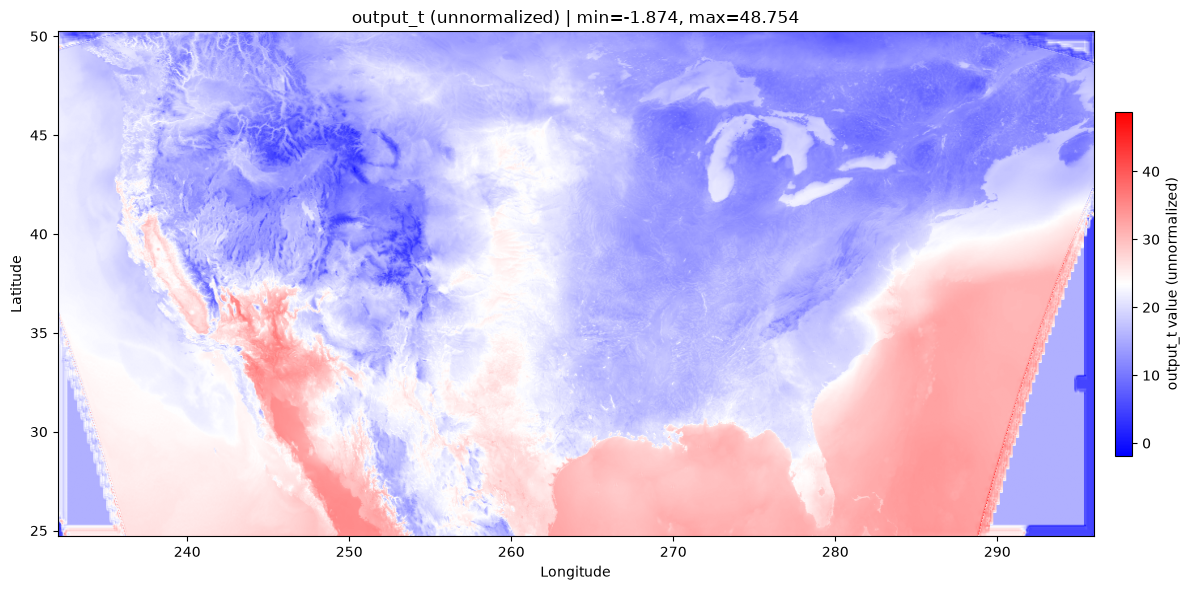

In [7]:
plot_output_channel(results, 'output_t')